# Markov DQN Pairs Trading
OLS beta · custom gym · PyTorch DQN

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
from collections import deque
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from pairs_trading_env_tc_newstate import PairsTradingEnv

# ── paste or import your env ──────────────────────────────────────────
# from pairs_trading_env import PairsTradingEnv
# If the file is in the same directory just uncomment the line above.
# Otherwise the full class is expected to be available as PairsTradingEnv.
# ─────────────────────────────────────────────────────────────────────

SEED = 72
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: cpu


## 1 · Load data & compute OLS beta

length: 532635
OLS  alpha=-1.3939  beta=1.0885
Spread  mean=-1.5573  std=0.7365


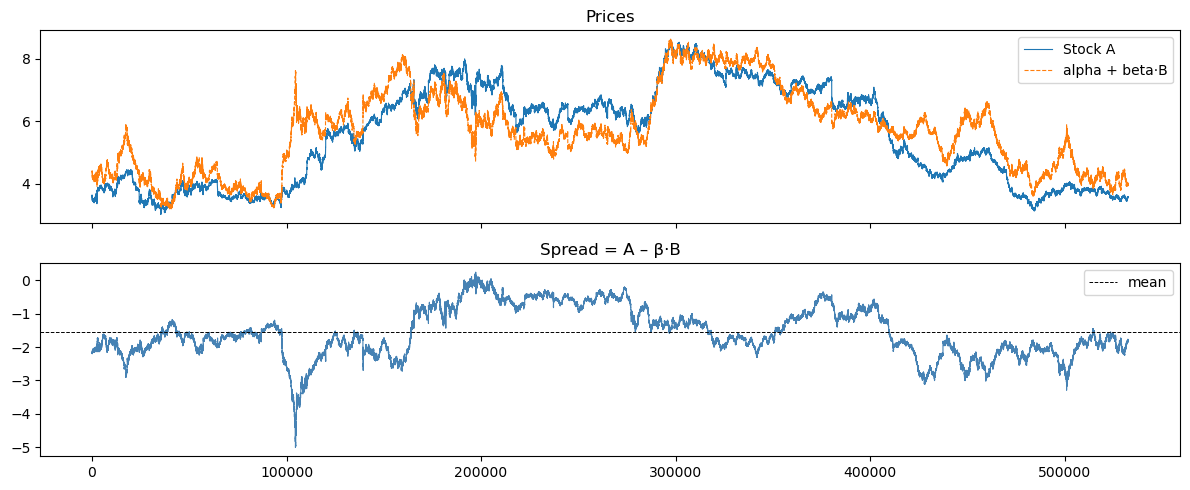

In [19]:
TRAIN_RATIO  = 0.80
# ── paths ─────────────────────────────────────────────────────────────
CSV_A = '../dataset/CORN_USD_2005_2020.csv'   # ← change to your file
CSV_B = '../dataset/WHEAT_USD_2005_2020.csv'   # ← change to your file
CSV_C = '../data-scripts/data.csv'
# ─────────────────────────────────────────────────────────────────────

df_a = pd.read_csv(CSV_A).dropna()
df_b = pd.read_csv(CSV_B).dropna()
# df_a = pd.read_csv(CSV_C)[['s1']].dropna()
# df_b = pd.read_csv(CSV_C)[['s2']].dropna()
# df_a = df_a.rename(columns={"s1": "close"})
# df_b = df_b.rename(columns={"s2": "close"})
# df_a = df_a[int(0*len(df_a)):int(len(df_a))]
# df_b = df_b[int(0*len(df_b)):int(len(df_b))]

df_a = df_a[int(0.2*len(df_a)):int(0.7*len(df_a))]
df_b = df_b[int(0.2*len(df_b)):int(0.7*len(df_b))]
n = len(df_a)
print(f"length: {n}")
# ── OLS: A = alpha + beta·B  →  beta = cov(A,B) / var(B) ────────────
A = df_a['close'].values
B = df_b['close'].values

split        = int(n * TRAIN_RATIO)
X = np.column_stack([np.ones(split), B[:split]])
beta_ols, _ = np.linalg.lstsq(X, A[:split], rcond=None)[0], None
alpha_ols = beta_ols[0]
beta      = beta_ols[1]
print(f'OLS  alpha={alpha_ols:.4f}  beta={beta:.4f}')

spread = A - beta * B
print(f'Spread  mean={spread.mean():.4f}  std={spread.std():.4f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(A, label='Stock A', linewidth=0.8)
axes[0].plot(beta * B + alpha_ols, label=f'alpha + beta·B', linewidth=0.8, linestyle='--')
axes[0].legend(); axes[0].set_title('Prices')
axes[1].plot(spread, linewidth=0.8, color='steelblue')
axes[1].axhline(spread.mean(), color='k', linestyle='--', linewidth=0.7, label='mean')
axes[1].set_title('Spread = A – β·B'); axes[1].legend()
plt.tight_layout(); plt.show()

## 2 · Train / test split

In [20]:

df_a_train, df_b_train = df_a.iloc[:split], df_b.iloc[:split]
df_a_test,  df_b_test  = df_a.iloc[split:].reset_index(drop=True), \
                          df_b.iloc[split:].reset_index(drop=True)

print(f'Train bars: {split}   Test bars: {n - split}')

Train bars: 426108   Test bars: 106527


## Markov chain on the train and test data

In [21]:
from hmmlearn import hmm
from scipy.special import logsumexp

MARKOV_STATES_NO = 3
    
def beta_windows(a, b, window_size):
    a_s, b_s = pd.Series(a), pd.Series(b)
    roll = lambda s: s.rolling(window_size, min_periods=2)
    cov = roll(b_s).cov(a_s)          # cov(b, a)
    var = roll(b_s).var()              # var(b)
    betas = -(cov / var).to_numpy()
    betas = np.nan_to_num(betas, nan=0.0, posinf=0.0, neginf=0.0)
    return betas
betas = beta_windows(A, B, 50000)
betas_train = betas[:split]
betas_test = betas[split:]

model = hmm.GaussianHMM(n_components=MARKOV_STATES_NO, covariance_type="full", n_iter=100)
model.fit(betas_train.reshape(-1, 1))

def forward_states(model, obs):
    log_emit  = model._compute_log_likelihood(obs)
    log_trans = np.log(model.transmat_)
    log_alpha = np.log(model.startprob_) + log_emit[0]
    states    = [int(np.argmax(log_alpha))]
    for t in range(1, len(obs)):
        log_alpha = log_emit[t] + logsumexp(log_alpha[:, None] + log_trans, axis=0)
        states.append(int(np.argmax(log_alpha)))
    return np.array(states)

train_states = model.predict(betas_train.reshape(-1, 1))
test_states  = forward_states(model, betas_test.reshape(-1, 1))

C:\Users\lpset\AppData\Local\Temp\ipykernel_14596\2966581759.py:24: RuntimeWarning: divide by zero encountered in log
  log_alpha = np.log(model.startprob_) + log_emit[0]


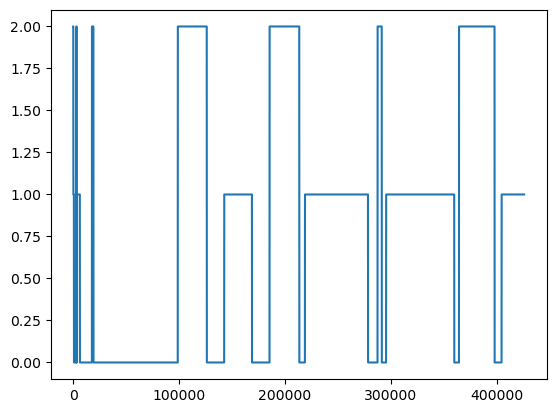

In [22]:
plt.plot(train_states)

## 3 · DQN components

In [23]:
# ── Hyper-parameters ──────────────────────────────────────────────────
TRANSACTION_COST = 0.0001     # flat cost per open / close
INITIAL_CASH     = 100.0

GAMMA            = 0.995    # discount factor
LR               = 1e-3    # learning rate
BATCH_SIZE       = 64
MEMORY_SIZE      = 50_000
TARGET_UPDATE    = 200     # steps between target-net syncs
N_EPISODES       = 100     # training episodes (each = full train series)

EPS_START        = 1.00
EPS_END          = 0.02
EPS_DECAY        = 0.98   # per-episode multiplicative decay
# ─────────────────────────────────────────────────────────────────────

STATE_DIM  = PairsTradingEnv.STATE_DIM   # 4
N_ACTIONS  = PairsTradingEnv.N_ACTIONS   # 3


# ── Q-Network ─────────────────────────────────────────────────────────
class QNet(nn.Module):
    def __init__(self, state_dim: int, n_actions: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# ── Replay buffer ─────────────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s2, d = zip(*batch)
        return (
            torch.tensor(np.array(s),  dtype=torch.float32, device=DEVICE),
            torch.tensor(a,            dtype=torch.long,    device=DEVICE),
            torch.tensor(r,            dtype=torch.float32, device=DEVICE),
            torch.tensor(np.array(s2), dtype=torch.float32, device=DEVICE),
            torch.tensor(d,            dtype=torch.float32, device=DEVICE),
        )

    def __len__(self): return len(self.buf)


# ── DQN agent ─────────────────────────────────────────────────────────
class DQNAgent:
    def __init__(self):
        self.policy_net = QNet(STATE_DIM, N_ACTIONS).to(DEVICE)
        self.target_net = QNet(STATE_DIM, N_ACTIONS).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR)
        self.memory    = ReplayBuffer(MEMORY_SIZE)
        self.steps     = 0
        self.epsilon   = EPS_START

    # ε-greedy selection
    def select_action(self, state: np.ndarray) -> int:
        if random.random() < self.epsilon:
            return random.randint(0, N_ACTIONS - 1)
        with torch.no_grad():
            t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            return int(self.policy_net(t).argmax(dim=1).item())

    def learn(self):
        if len(self.memory) < BATCH_SIZE:
            return

        s, a, r, s2, done = self.memory.sample(BATCH_SIZE)

        # Current Q values
        q_vals = self.policy_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

        # Double-DQN target
        with torch.no_grad():
            best_actions = self.policy_net(s2).argmax(dim=1, keepdim=True)
            q_next       = self.target_net(s2).gather(1, best_actions).squeeze(1)
            target       = r + GAMMA * q_next * (1 - done)

        loss = nn.SmoothL1Loss()(q_vals, target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        self.steps += 1
        if self.steps % TARGET_UPDATE == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(EPS_END, self.epsilon * EPS_DECAY)

## 4 · Training loop

In [24]:
agents = []
for i in range(MARKOV_STATES_NO):
    agents.append(DQNAgent())

# train_states, test_states

In [25]:
def make_train_env():
    return PairsTradingEnv(
        df_a_train, df_b_train,
        beta            = beta,
        operation_penalty = TRANSACTION_COST*10,
        initial_cash    = INITIAL_CASH,
    )

train_env  = make_train_env()

ep_returns = []

for ep in range(1, N_EPISODES + 1):
    obs  = train_env.reset()
    done = False
    ep_reward = 0.0
    cnts = np.zeros(MARKOV_STATES_NO)
    while not done:
        state = train_states[train_env.current_step]
        action            = agents[state].select_action(obs)
        obs2, reward, done, _ = train_env.step(action)
        agents[state].memory.push(obs, action, reward, obs2, float(done))
        cnts[state]+=1
        if cnts[state]%64==0:
            agents[state].learn()
        ep_reward += reward
        obs        = obs2

    for i in range(MARKOV_STATES_NO):
        agents[i].decay_epsilon()
    ep_returns.append(ep_reward)

    if ep % 10 == 0:
        recent = np.mean(ep_returns[-10:])
        print(f'Episode {ep:4d}/{N_EPISODES}  '
            f'return={ep_reward:+8.3f}  '
            f'avg10={recent:+8.3f}  '
            f'ε={agents[0].epsilon:.3f}  '
            f'mem={len(agents[0].memory)}')

print('Training complete.')

Episode   10/100  return= -99.971  avg10= -99.980  ε=0.817  mem=25065
Episode   20/100  return= -99.958  avg10= -99.954  ε=0.668  mem=50000
Episode   30/100  return= -99.624  avg10= -99.849  ε=0.545  mem=50000
Episode   40/100  return= -99.507  avg10= -99.543  ε=0.446  mem=50000
Episode   50/100  return= -98.015  avg10= -98.913  ε=0.364  mem=50000
Episode   60/100  return= -96.526  avg10= -96.299  ε=0.298  mem=50000
Episode   70/100  return= -91.930  avg10= -93.284  ε=0.243  mem=50000
Episode   80/100  return= -84.473  avg10= -88.384  ε=0.199  mem=50000
Episode   90/100  return= -77.769  avg10= -82.992  ε=0.162  mem=50000
Episode  100/100  return= -79.794  avg10= -77.103  ε=0.133  mem=50000
Training complete.


## 5 · Evaluation on test set

In [26]:
def run_episode(env: PairsTradingEnv, agents: list[DQNAgent], greedy: bool = True):
    """Run one episode; return per-step info dicts."""
    obs  = env.reset(is_test=True)
    done = False
    log  = []

    # Freeze epsilon for greedy evaluation
    saved_eps = agents[0].epsilon
    if greedy:
        for i in range(MARKOV_STATES_NO):
            agents[i].epsilon = 0.0

    while not done:
        state = test_states[env.current_step]
        action = agents[state].select_action(obs)
        obs, reward, done, info = env.step(action)
        info['action'] = action
        info['reward'] = reward
        log.append(info)

    for i in range(MARKOV_STATES_NO):
            agents[i].epsilon = saved_eps
    return pd.DataFrame(log)

test_env = PairsTradingEnv(
    df_a_test, df_b_test,
    beta            = beta,
    operation_penalty= TRANSACTION_COST,
    initial_cash    = INITIAL_CASH,
    df_a_train = df_a_train,
    df_b_train = df_b_train
)

log = run_episode(test_env, agents, greedy=True)

total_return = log['portfolio_value'].iloc[-1] - INITIAL_CASH
total_trades = (log['action'] != 1).sum()   # rough: non-HOLD steps
print(f'Test  total P&L : {total_return:+.4f}')
print(f'Test  final value: {log["portfolio_value"].iloc[-1]:.4f}')
print(f'Test  realized PnL: {log["realized_pnl"].iloc[-1]:+.4f}')
print(f'Test  non-hold steps: {total_trades}')

Test  total P&L : +13.0126
Test  final value: 113.0126
Test  realized PnL: +13.0126
Test  non-hold steps: 20508


### Test plots

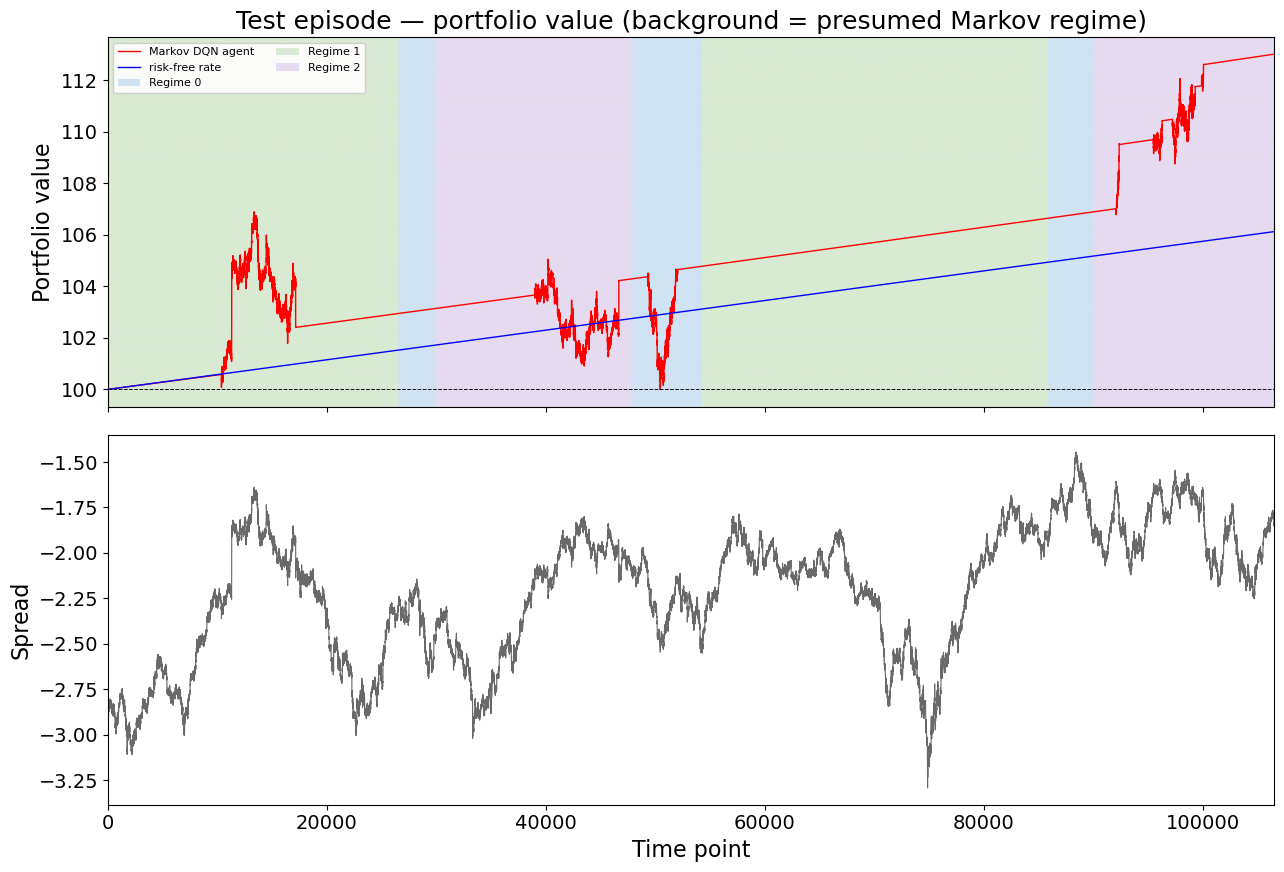

In [32]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.size':        16,
    'axes.titlesize':   18,
    'axes.labelsize':   16,
    'xtick.labelsize':  14,
    'ytick.labelsize':  14,
    'legend.fontsize':  14,
})
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# ── Portfolio value, with background shaded by the presumed regime ───
ax = axes[0]

n_pts   = len(log['portfolio_value'])
regimes = test_states[:n_pts]               # regime presumed active at each test-set step

# Soft, print-friendly, colour-blind-safe palette — picked to stay clear of
# the orange/red foreground lines. Extend this list if MARKOV_STATES_NO > 6.
REGIME_PALETTE = ['#cfe3f3', '#d9ead3', '#e6dbf0', '#fbe7c6', '#f3d1d8', '#d6e6e6']
regime_colors  = REGIME_PALETTE[:MARKOV_STATES_NO]
regime_cmap    = ListedColormap(regime_colors)

line1, = ax.plot(log['portfolio_value'], color='red', linewidth=1, label='Markov DQN agent', zorder=3)
line2, = ax.plot(np.linspace(100, 100*(1.000000558 ** n_pts), n_pts), color='blue', linewidth=1,
                  label='risk-free rate', zorder=3)
ax.axhline(INITIAL_CASH, color='k', linestyle='--', linewidth=0.7, zorder=3)

# Fix the y-limits first, then draw the regime background as a single image —
# one draw call regardless of how many points/regime switches there are, so
# it stays fast even with tens of thousands of steps (axvspan-per-step is not).
ax.relim(); ax.autoscale_view()
ymin, ymax = ax.get_ylim()
ax.imshow(
    regimes[np.newaxis, :],
    aspect='auto',
    cmap=regime_cmap,
    vmin=0, vmax=MARKOV_STATES_NO - 1,
    extent=(0, n_pts, ymin, ymax),
    origin='lower',
    alpha=1,
    zorder=0,
)
ax.set_ylim(ymin, ymax)

regime_handles = [Patch(facecolor=c, edgecolor='none', label=f'Regime {i}')
                  for i, c in enumerate(regime_colors)]
ax.legend(handles=[line1, line2, *regime_handles], loc='upper left',
          fontsize=8, ncol=2, framealpha=0.9)

ax.set_ylabel('Portfolio value')
ax.set_title('Test episode — portfolio value (background = presumed Markov regime)')

# ── Spread + z-score + position shading ──────────────────────────────
ax = axes[1]
ax.plot(log['spread'], color='dimgray', linewidth=0.8, label='Spread')

# shade long / short periods
# pos = log['position'][:100].values
# for i in range(len(pos)):
#     if pos[i] == 1:
#         ax.axvspan(i, i + 1, alpha=0.15, color='green')
#     elif pos[i] == -1:
#         ax.axvspan(i, i + 1, alpha=0.15, color='red')

ax.set_ylabel('Spread')
ax.set_xlabel('Time point')
# ax.legend(['Spread', 'Short (red)', 'Long (green)'], fontsize=8)

plt.tight_layout()
plt.show()

In [28]:
# Simpler version
returns = log['portfolio_value'].pct_change().dropna()
sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(67800)

print(f"Annualized Sharpe Ratio: {sharpe_ratio:.4f}")

Annualized Sharpe Ratio: 1.2582
